In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de la superficie (función de costo)
def f(x, y):
    return (
        np.sin(1.5 * x) * np.cos(1.5 * y)
        + 0.5 * np.sin(3 * x) * np.sin(3 * y)
        + 0.08 * (x**2 + y**2)
    )

# 2. Gradiente analítico: [df/dx, df/dy]
def grad_f(x, y):
    df_dx = (
        1.5 * np.cos(1.5 * x) * np.cos(1.5 * y)
        + 1.5 * np.cos(3 * x) * np.sin(3 * y)
        + 0.16 * x
    )
    df_dy = (
        -1.5 * np.sin(1.5 * x) * np.sin(1.5 * y)
        + 1.5 * np.sin(3 * x) * np.cos(3 * y)
        + 0.16 * y
    )
    return np.array([df_dx, df_dy])

# 3. Malla 3D para el paisaje
x_vals = np.linspace(-3, 3, 200)
y_vals = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f(X, Y)

# 4. Descenso de gradiente desde la cima de una montañita
x_curr, y_curr = 0.60, 0.40  # Punto inicial sobre la colina
lr = 0.07                     # Tasa de aprendizaje (learning rate)
iterations = 22

path = [(x_curr, y_curr, f(x_curr, y_curr))]
for _ in range(iterations):
    grad = grad_f(x_curr, y_curr)
    x_curr -= lr * grad[0]
    y_curr -= lr * grad[1]
    path.append((x_curr, y_curr, f(x_curr, y_curr)))

path = np.array(path)

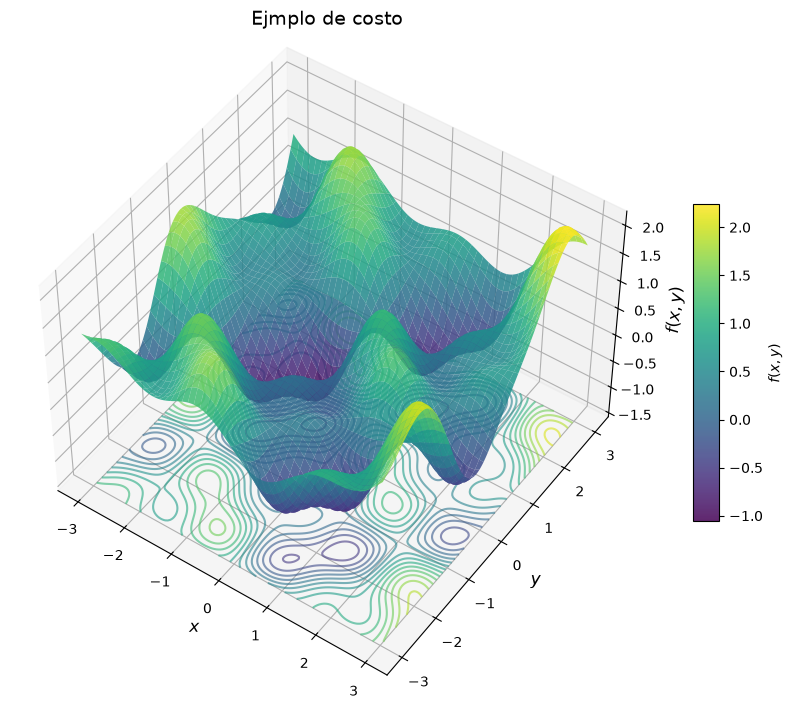

In [3]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Superficie
surf = ax.plot_surface(
    X, Y, Z,
    cmap='viridis',
    alpha=0.85,
    edgecolor='none',
    antialiased=True
)

# Proyección de contornos en la base
ax.contour(X, Y, Z, zdir='z', offset=np.min(Z) - 0.5, cmap='viridis', levels=20, alpha=0.6)

# Configuración visual
ax.set_title("Ejmplo de costo", fontsize=14, pad=15)
ax.set_xlabel("$x$", fontsize=12)
ax.set_ylabel("$y$", fontsize=12)
ax.set_zlabel("$f(x, y)$", fontsize=12)
ax.set_zlim(np.min(Z) - 0.5, np.max(Z))
ax.view_init(elev=48, azim=-55)  # Ángulo de visión óptimo
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=12, label="$f(x, y)$")

plt.tight_layout()
plt.show()

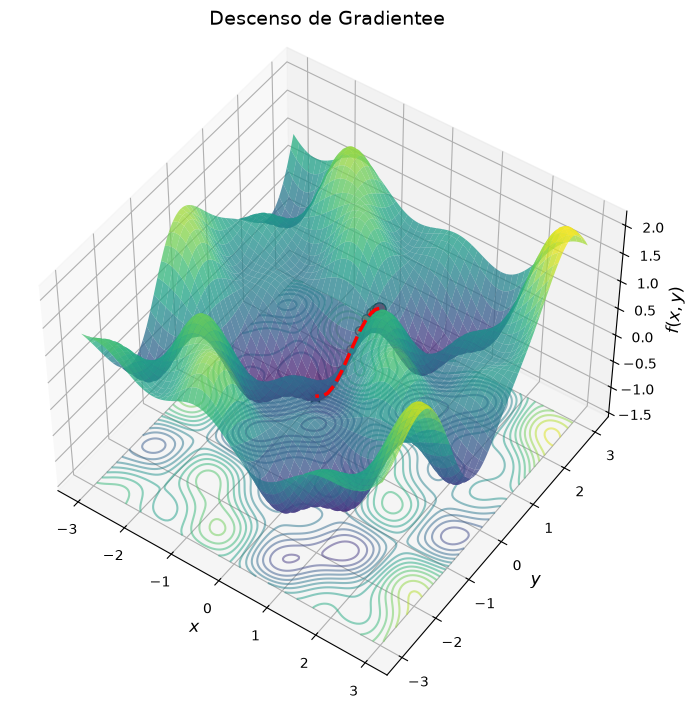

In [5]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 1. Superficie con un toque más de transparencia para destacar los puntos
surf = ax.plot_surface(
    X, Y, Z,
    cmap='viridis',
    alpha=0.75,
    edgecolor='none',
    antialiased=True
)

# Contornos en la base
ax.contour(X, Y, Z, zdir='z', offset=np.min(Z) - 0.5, cmap='viridis', levels=20, alpha=0.5)

# 2. Trayectoria de Descenso de Gradiente
# Línea que une los pasos (ligeramente levantada en z para no quedar oculta)
ax.plot(
    path[:, 0], path[:, 1], path[:, 2] + 0.05,
    color='red',
    linewidth=2.5,
    linestyle='--',
    label='Ruta del Gradiente',
    zorder=10
)

# Puntos intermedios
ax.scatter(
    path[1:-1, 0], path[1:-1, 1], path[1:-1, 2] + 0.05,
    color='darkorange',
    s=40,
    edgecolors='black',
    alpha=0.9,
    label='Pasos intermedios',
    zorder=11
)

# Punto inicial (Cima)
ax.scatter(
    path[0, 0], path[0, 1], path[0, 2] + 0.05,
    color='crimson',
    s=90,
    marker='o',
    edgecolors='black',
    label='Inicio (Colina)',
    zorder=12
)

# Punto final (Valle / Mínimo)
ax.scatter(
    path[-1, 0], path[-1, 1], path[-1, 2] + 0.05,
    color='cyan',
    s=110,
    marker='*',
    edgecolors='black',
    label='Convergencia (Valle)',
    zorder=12
)

# Configuración visual
ax.set_title("Descenso de Gradientee", fontsize=14, pad=15)
ax.set_xlabel("$x$", fontsize=12)
ax.set_ylabel("$y$", fontsize=12)
ax.set_zlabel("$f(x, y)$", fontsize=12)
ax.set_zlim(np.min(Z) - 0.5, np.max(Z))
ax.view_init(elev=48, azim=-55)

plt.tight_layout()
plt.show()

In [16]:
# Centro del paraboloide
center = np.array([25.0, 25.0])

# Coeficiente de curvatura simétrico (forma circular perfecta)
# J(w1, w2) = k * ((w1 - c1)^2 + (w2 - c2)^2)
k = 0.005

def J(w1, w2):
    return k * ((w1 - center[0])**2 + (w2 - center[1])**2)

# Dominio amplio para apreciar la apertura completa del tazón
w1_vals = np.linspace(-20, 70, 300)
w2_vals = np.linspace(-20, 70, 300)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Z = J(W1, W2)

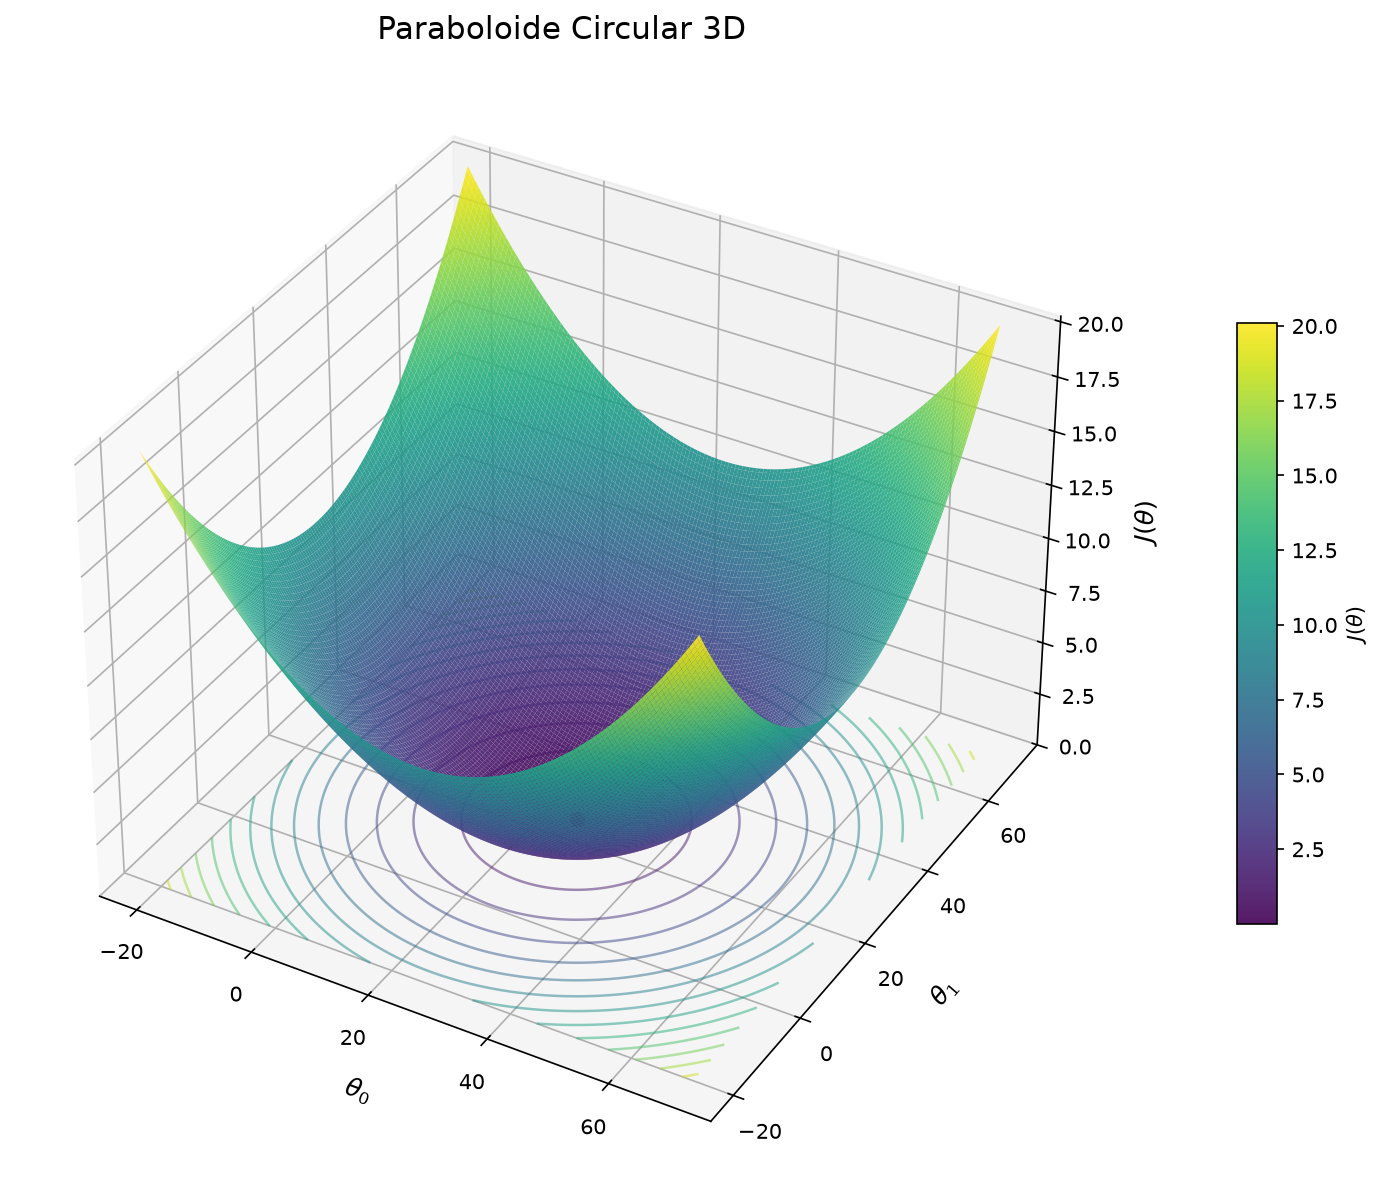

In [ ]:
fig = plt.figure(figsize=(11, 8), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# Superficie 3D suave
surf = ax.plot_surface(
    W1, W2, Z,
    cmap='viridis',
    rstride=2,
    cstride=2,
    alpha=0.9,
    edgecolor='none',
    antialiased=True
)

# Proyección de anillos circulares en la base
ax.contour(
    W1, W2, Z,
    zdir='z',
    offset=0,
    levels=15,
    cmap='viridis',
    linewidths=1.2,
    alpha=0.5
)

# Punto del mínimo en el vértice inferior
ax.scatter([center[0]], [center[1]], [0], color='crimson', s=40, zorder=10)

# Ajuste visual
ax.set_title("Funcion de Costo", fontsize=15, pad=18)
ax.set_xlabel("$\\theta_0$", fontsize=12, labelpad=8)
ax.set_ylabel("$\\theta_1$", fontsize=12, labelpad=8)
ax.set_zlabel("$J(\\theta)$", fontsize=12, labelpad=8)
ax.set_zlim(0, np.max(Z))

# Perspectiva aérea simétrica
ax.view_init(elev=35, azim=-60)

fig.colorbar(surf, ax=ax, shrink=0.55, aspect=15, pad=0.08, label="$J(\\theta)$")
plt.tight_layout()
plt.show()

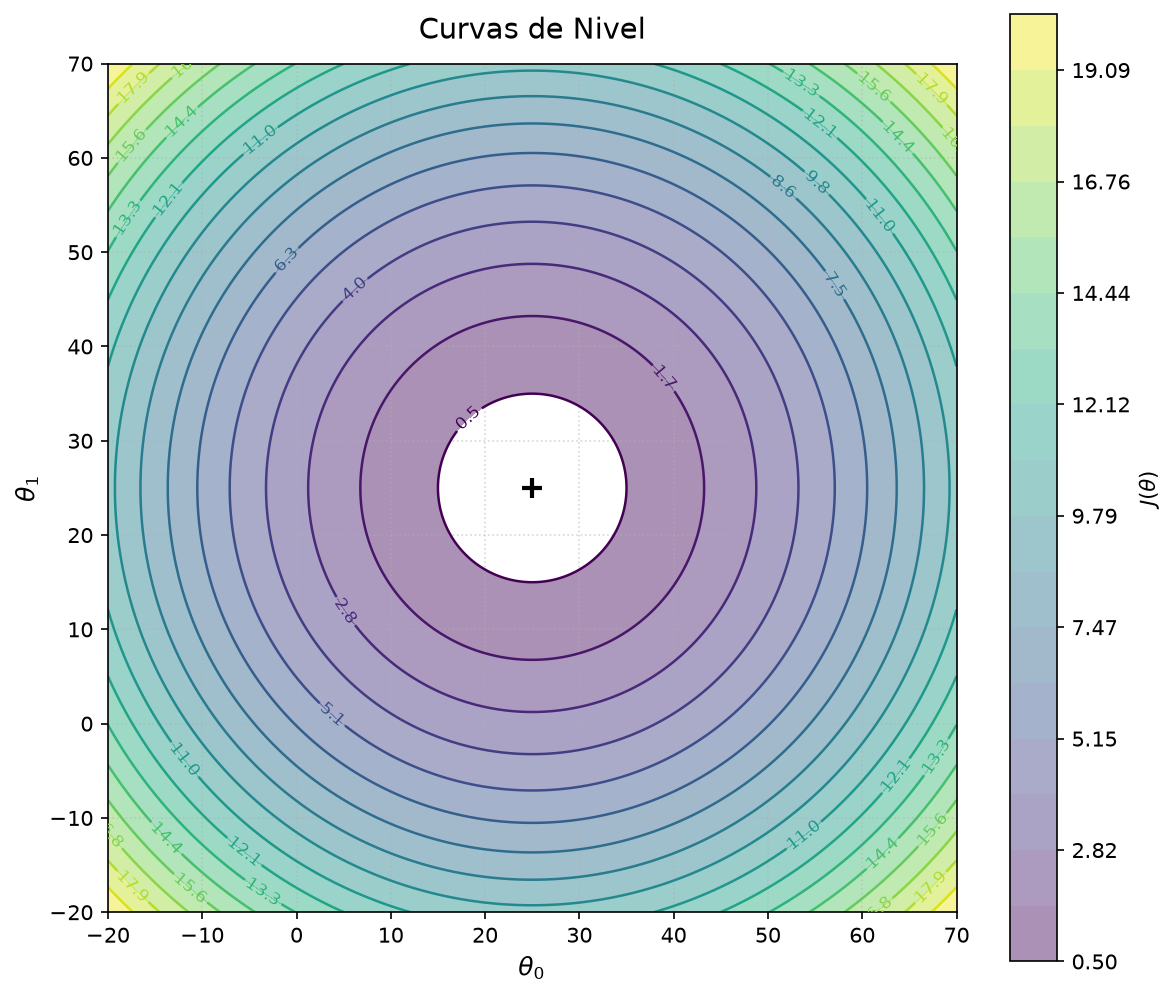

In [17]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=150)

# Niveles concéntricos
levels = np.linspace(0.5, np.max(Z), 18)

# Relleno de color suave
cf = ax.contourf(W1, W2, Z, levels=levels, cmap='viridis', alpha=0.45)

# Anillos concéntricos nítidos
cs = ax.contour(W1, W2, Z, levels=levels, cmap='viridis', linewidths=1.2)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f')

# Mínimo central
ax.plot(center[0], center[1], marker='+', color='black', markersize=10, markeredgewidth=2)

# Ajustes
ax.set_title("Curvas de Nivel", fontsize=14, pad=12)
ax.set_xlabel("$\\theta_0$", fontsize=12)
ax.set_ylabel("$\\theta_1$", fontsize=12)
ax.set_xlim(-20, 70)
ax.set_ylim(-20, 70)
ax.set_aspect('equal')
ax.grid(True, linestyle=':', alpha=0.5)

fig.colorbar(cf, ax=ax, shrink=0.82, label="$J(\\theta)$")
plt.tight_layout()
plt.show()